# imports

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor
from muutils.json_serialize import json_serialize

# attention-motifs
from attention_motifs.features.analysis import (
	build_distance_tensor,
	DistanceTensorResult,
)
from attention_motifs.features.plotting import (
	plot_embedding,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

# load data

In [ ]:
DF_PCA: pl.DataFrame = pl.read_ndjson(PATH_BASE / "pca.jsonl")

feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.mean,feat.first_tok.linreg.r2,feat.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.diag.L1_norm,feat.diag.variance,feat.markov_transition.diff.entropy,feat.markov_transition.diff.linreg.r2,feat.diag.linreg.r2,feat.first_tok.energy,feat.gram.row.beta_hist.hist.raw.median,feat.diag.kurtosis,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.diag.psd_total_power,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.autocorr_lag1,feat.gram.row.beta_hist.hist.raw.rms,feat.markov_transition.diff.std,feat.log.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.diag.linreg.slope,feat.markov_transition.diff.L1_norm,activation.cls,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.diag.rms,feat.diag.energy,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.variance,…,feat.log.gram.row.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.std,feat.markov_transition.diff.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.energy,feat.markov_transition.diff.kurtosis,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.median,feat.diag.linreg.intercept,activation.model,feat.diag.entropy,feat.markov_transition.diff.skewness,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.median,feat.first_tok.entropy,feat.log.gram.skew.beta_hist.hist.raw.std,feat.first_tok.std,feat.markov_transition.diff.mean,feat.gram.col.beta_hist.hist.raw.linreg.r2,feat.first_tok.variance,feat.first_tok.L1_norm,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.linreg.intercept,feat.gram.row.beta_hist.hist.raw.entropy,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.diff.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.839435,-0.008704,0.796153,0.862457,-0.7244,-0.77165,-0.288697,-0.554036,-0.724653,0.204746,1.435507,-0.245457,-0.264634,-0.986983,0.075595,0.55133,-1.266912,0.988711,0.210352,1.450932,0.870882,-1.946191,-0.32214,-0.21145,-0.266664,-1.580293,0.892255,-0.780488,0.514015,-0.266285,"""gemma-2b:L0:H0""",0.493229,0.442892,0.065533,0.989938,0.814896,0.987323,…,0.839435,-0.30592,0.279448,1.023283,0.305812,-0.266664,-0.238897,-0.057261,-0.373188,0.659782,-0.692114,1.532475,0.045931,"""gemma-2b""",0.963007,0.038684,-0.692114,0.060201,-2.15458,-0.552569,0.604305,-0.277801,0.833364,-0.266285,-0.792824,0.776566,0.24403,-0.288697,-0.863237,-0.392105,-0.339936,0.155735,1.455366,-0.32214,-0.283626,0.902994,-0.266285
0.839435,-0.152863,0.87716,0.862457,-0.7244,-1.136242,0.343294,0.544505,-0.724653,-0.382406,-0.407666,-0.245457,-0.264634,-0.613823,0.08324,0.947212,0.400592,1.070952,0.251842,-0.290415,1.32667,-2.216734,0.05645,-0.21145,-0.268737,0.44

# distances between heads

In [ ]:
head_dists: DistanceTensorResult = build_distance_tensor(
	DF_PCA,
	feature_prefix="pc.",
)
dbg_tensor(head_dists.distances)
head_dists_mean = head_dists.distances.mean(axis=-1)
dbg_tensor(head_dists_mean)
print()

[ <ipykernel>:5 ] head_dists.distances: μ=11.56 σ=5.78 x̃=10.62 R=[0.00,43.31] ℙ=|▃█▄▁   | shape=(800,800,128) dtype=float64
[ <ipykernel>:7 ] head_dists_mean: μ=11.56 σ=5.29 x̃=10.55 R=[0.00,36.34] ℙ=|▁█▅▂   | shape=(800,800) dtype=float64


In [ ]:
with open(PATH_BASE / "head_dists.json", "w") as f:
	json.dump(
		json_serialize(
			dict(
				labels=head_dists.cls_values,
				dists=head_dists_mean,
			)
		),
		f,
	)

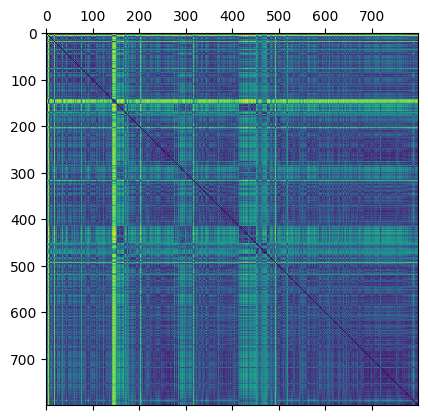

In [17]:
plt.matshow(head_dists_mean)

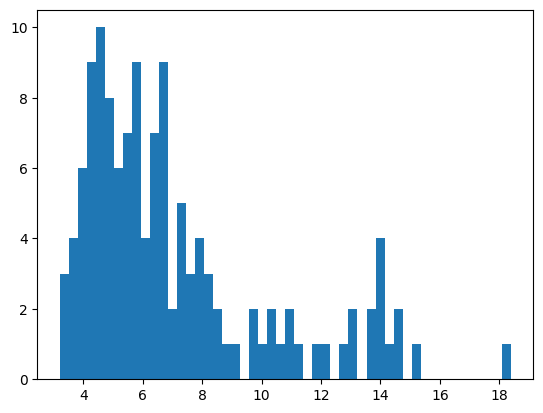

In [18]:
plt.hist(
	head_dists.distances[0, 1],
	bins=50,
)
print()

In [29]:
def load_attnpedia(
	path: str | Path = Path("../data/attn-pedia.json"),
	remove_papers: list[str] | None = None,
) -> pl.DataFrame:
	"""Load the attnpedia data."""
	data_raw: dict = json.load(open(path, "r"))
	data: list[dict] = list()
	for paper in data_raw:
		model_name: str = paper["model"]

		if remove_papers is not None and paper["prefix"] in remove_papers:
			continue

		for head_cls in paper["classes"]:
			for h in head_cls["heads"]:
				data.append(
					{
						"head": f"{model_name}:{h}",
						"type": f"{paper['prefix']}:{head_cls['type']}",
					}
				)

	return data


ATTNPEDIA: list[dict[str, str]] = load_attnpedia(remove_papers=["greater-than"])

ATTNPEDIA_HEAD_TO_TYPES: dict[str, list[str]] = dict()
for head in ATTNPEDIA:
	if head["head"] not in ATTNPEDIA_HEAD_TO_TYPES:
		ATTNPEDIA_HEAD_TO_TYPES[head["head"]] = list()
	ATTNPEDIA_HEAD_TO_TYPES[head["head"]].append(head["type"])


ATTNPEDIA_TYPE_TO_HEAD: dict[str, list[str]] = dict()
for head in ATTNPEDIA:
	if head["type"] not in ATTNPEDIA_TYPE_TO_HEAD:
		ATTNPEDIA_TYPE_TO_HEAD[head["type"]] = list()
	ATTNPEDIA_TYPE_TO_HEAD[head["type"]].append(head["head"])

ATTNPEDIA_HEAD_TO_TYPE: dict[str, str] = {
	head: types[0] for head, types in ATTNPEDIA_HEAD_TO_TYPES.items()
}

ATTNPEDIA_HEAD_TO_TYPE

{'gpt2-small:L2:H2': 'IOI:Previous Token',
 'gpt2-small:L4:H11': 'IOI:Previous Token',
 'gpt2-small:L0:H1': 'IOI:Duplicate Token',
 'gpt2-small:L3:H0': 'IOI:Duplicate Token',
 'gpt2-small:L0:H10': 'IOI:Duplicate Token',
 'gpt2-small:L5:H5': 'IOI:Induction',
 'gpt2-small:L6:H9': 'IOI:Induction',
 'gpt2-small:L5:H8': 'IOI:Induction',
 'gpt2-small:L5:H9': 'IOI:Induction',
 'gpt2-small:L7:H3': 'IOI:S-Inhibition',
 'gpt2-small:L7:H9': 'IOI:S-Inhibition',
 'gpt2-small:L8:H6': 'IOI:S-Inhibition',
 'gpt2-small:L8:H10': 'IOI:S-Inhibition',
 'gpt2-small:L10:H7': 'IOI:Negative Name Mover',
 'gpt2-small:L11:H10': 'IOI:Negative Name Mover',
 'gpt2-small:L9:H9': 'IOI:Name Mover',
 'gpt2-small:L9:H6': 'IOI:Name Mover',
 'gpt2-small:L10:H0': 'IOI:Name Mover',
 'gpt2-small:L9:H0': 'IOI:Backup Name Mover',
 'gpt2-small:L9:H7': 'IOI:Backup Name Mover',
 'gpt2-small:L10:H1': 'IOI:Backup Name Mover',
 'gpt2-small:L10:H2': 'IOI:Backup Name Mover',
 'gpt2-small:L10:H6': 'IOI:Backup Name Mover',
 'gpt2-small:

/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 822 with accuracies 
[1.01063943e-14 2.32647282e-06 7.21516029e-06 4.25098926e-07]
not reaching the requested tolerance 2.4139881134033203e-06.
Use iteration 822 instead with accuracy 
2.4916830101544927e-06.

  _, diffusion_map = lobpcg(
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[5.57305433e-15 2.32648209e-06 7.21515694e-06 4.25104644e-07]
not reaching the requested tolerance 2.4139881134033203e-06.
  _, diffusion_map = lobpcg(


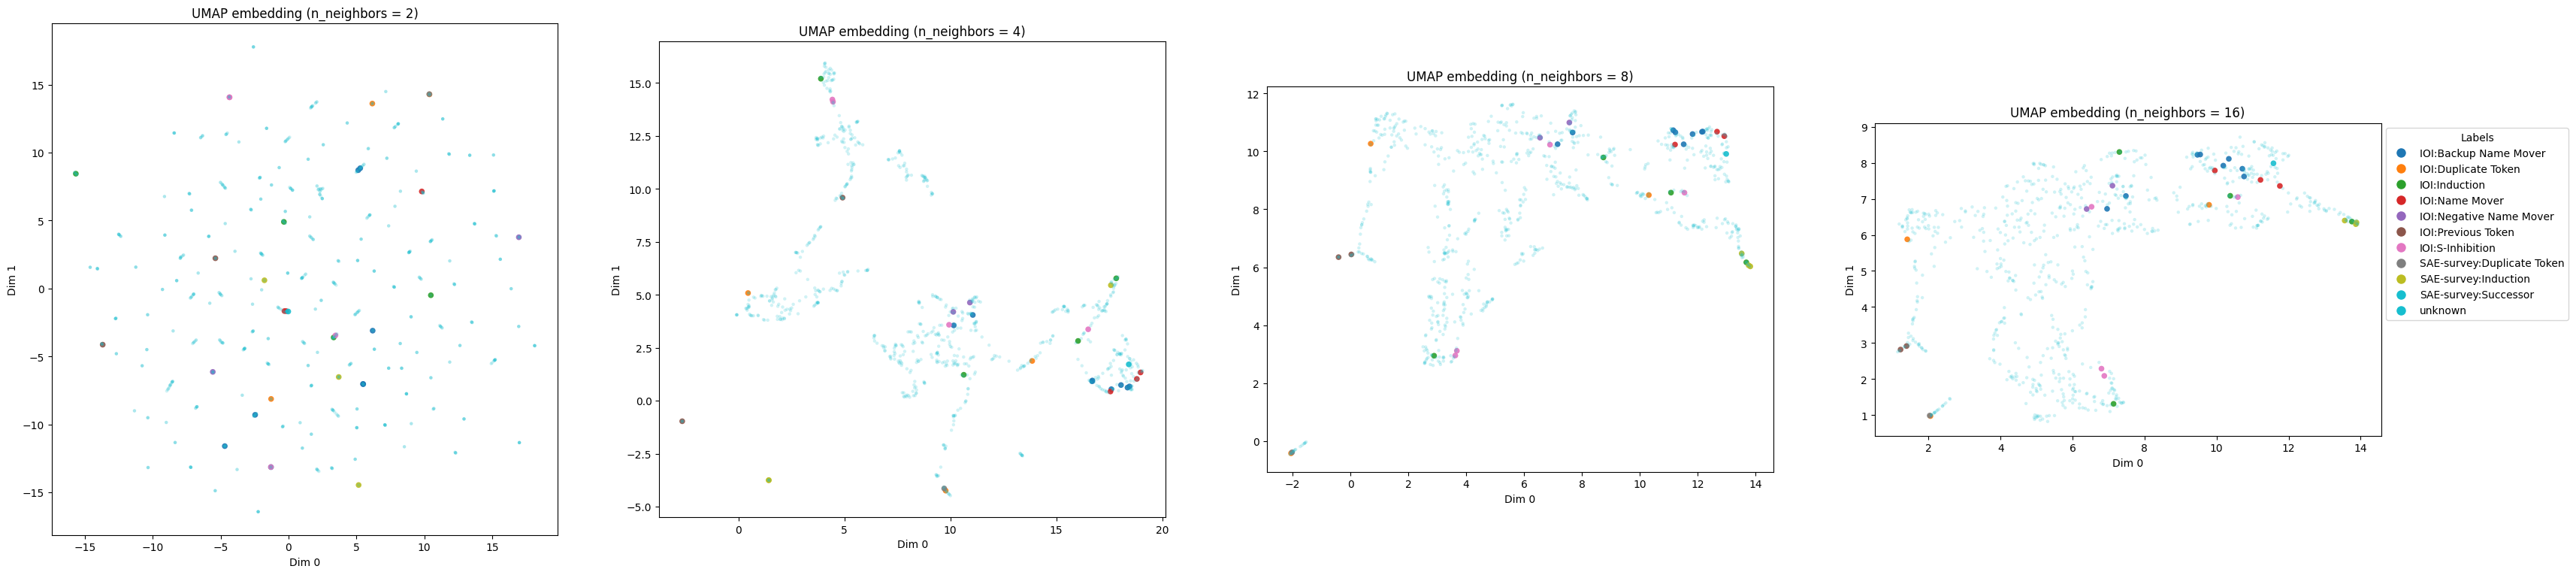

In [ ]:
warnings.filterwarnings(
	action="ignore",
	category=FutureWarning,
	message=r"'force_all_finite' was renamed to 'ensure_all_finite'",
	module=r"^sklearn\.utils\.deprecation$",
)
warnings.filterwarnings(
	"ignore",
	category=UserWarning,
	message=r"using precomputed metric; inverse_transform will be unavailable",
	module=r"^umap\.umap_$",
)
warnings.filterwarnings(
	"ignore",
	category=UserWarning,
	message=r"n_jobs value .* overridden .* random_state",
	module=r"^umap\.umap_$",
)

n_neighbors_lst: list[int] = [2, 4, 8, 16]  # , 32, 64, 128, 256, 512]
fig, ax = plt.subplots(
	nrows=1,
	ncols=len(n_neighbors_lst),
	figsize=(10 * len(n_neighbors_lst), 10),
)
for i, n_neighbors in enumerate(n_neighbors_lst):
	reducer: umap.UMAP = umap.UMAP(
		n_components=2,
		metric="precomputed",
		init="spectral",
		n_neighbors=n_neighbors,
		min_dist=0.1,
		random_state=0,
	)
	embedding: np.ndarray = reducer.fit_transform(head_dists_mean)

	# scatter plot
	plot_embedding(
		embedding,
		# labels=pl.Series([f.split(":")[0] for f in head_dists.cls_values]),
		labels=pl.Series(
			[ATTNPEDIA_HEAD_TO_TYPE.get(f, "unknown") for f in head_dists.cls_values]
		),
		dims=(0, 1),
		alpha={
			"unknown": 0.2,
			None: 0.9,
		},
		marker_size={
			"unknown": 10,
			None: 30,
		},
		title=f"UMAP embedding ({n_neighbors = })",
		ax=ax[i],
	)
plt.show()

# plt.figure(figsize=(8, 6))
# plt.scatter(embedding[:, 0], embedding[:, 1], s=10)  # no explicit colours
# plt.xlabel("UMAP 0")
# plt.ylabel("UMAP 1")
# plt.title("UMAP embedding")
# plt.tight_layout()
# plt.show()

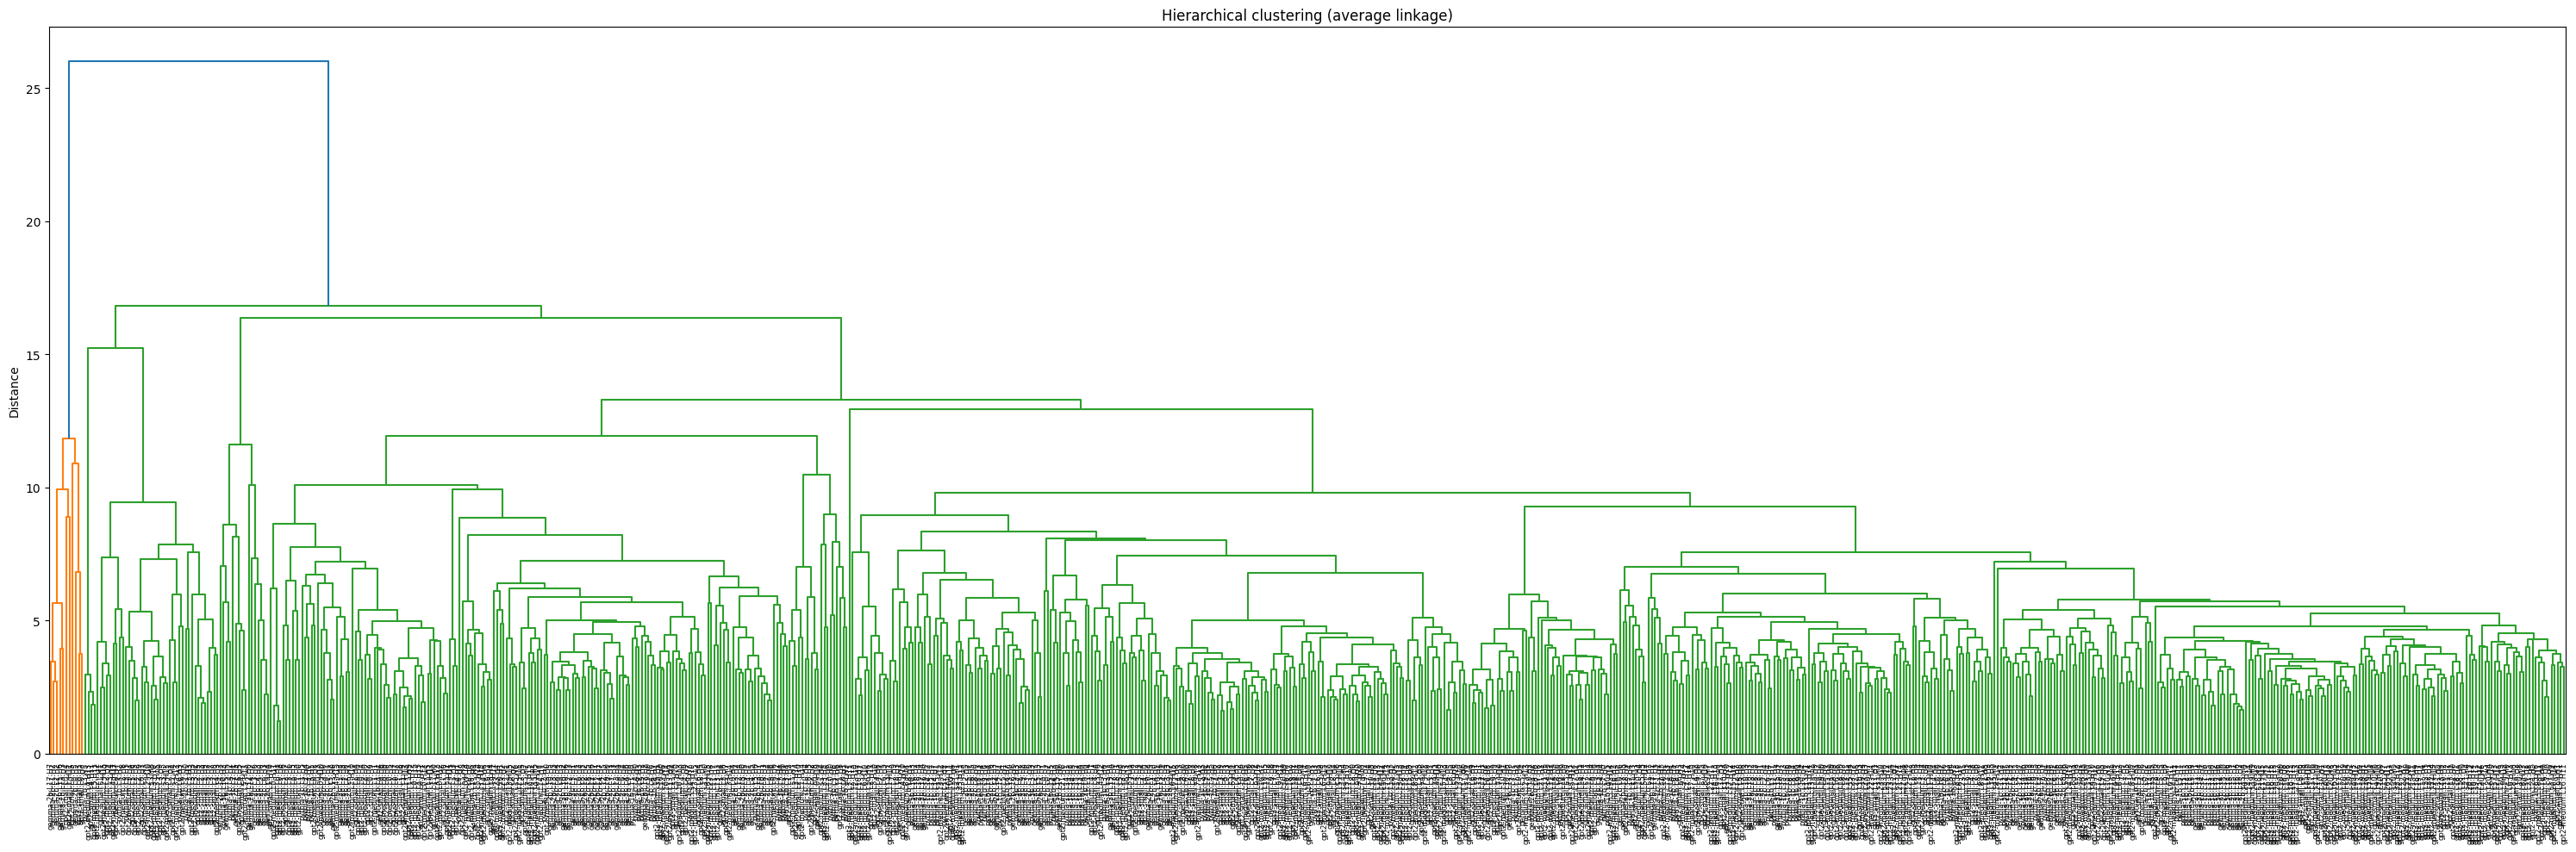

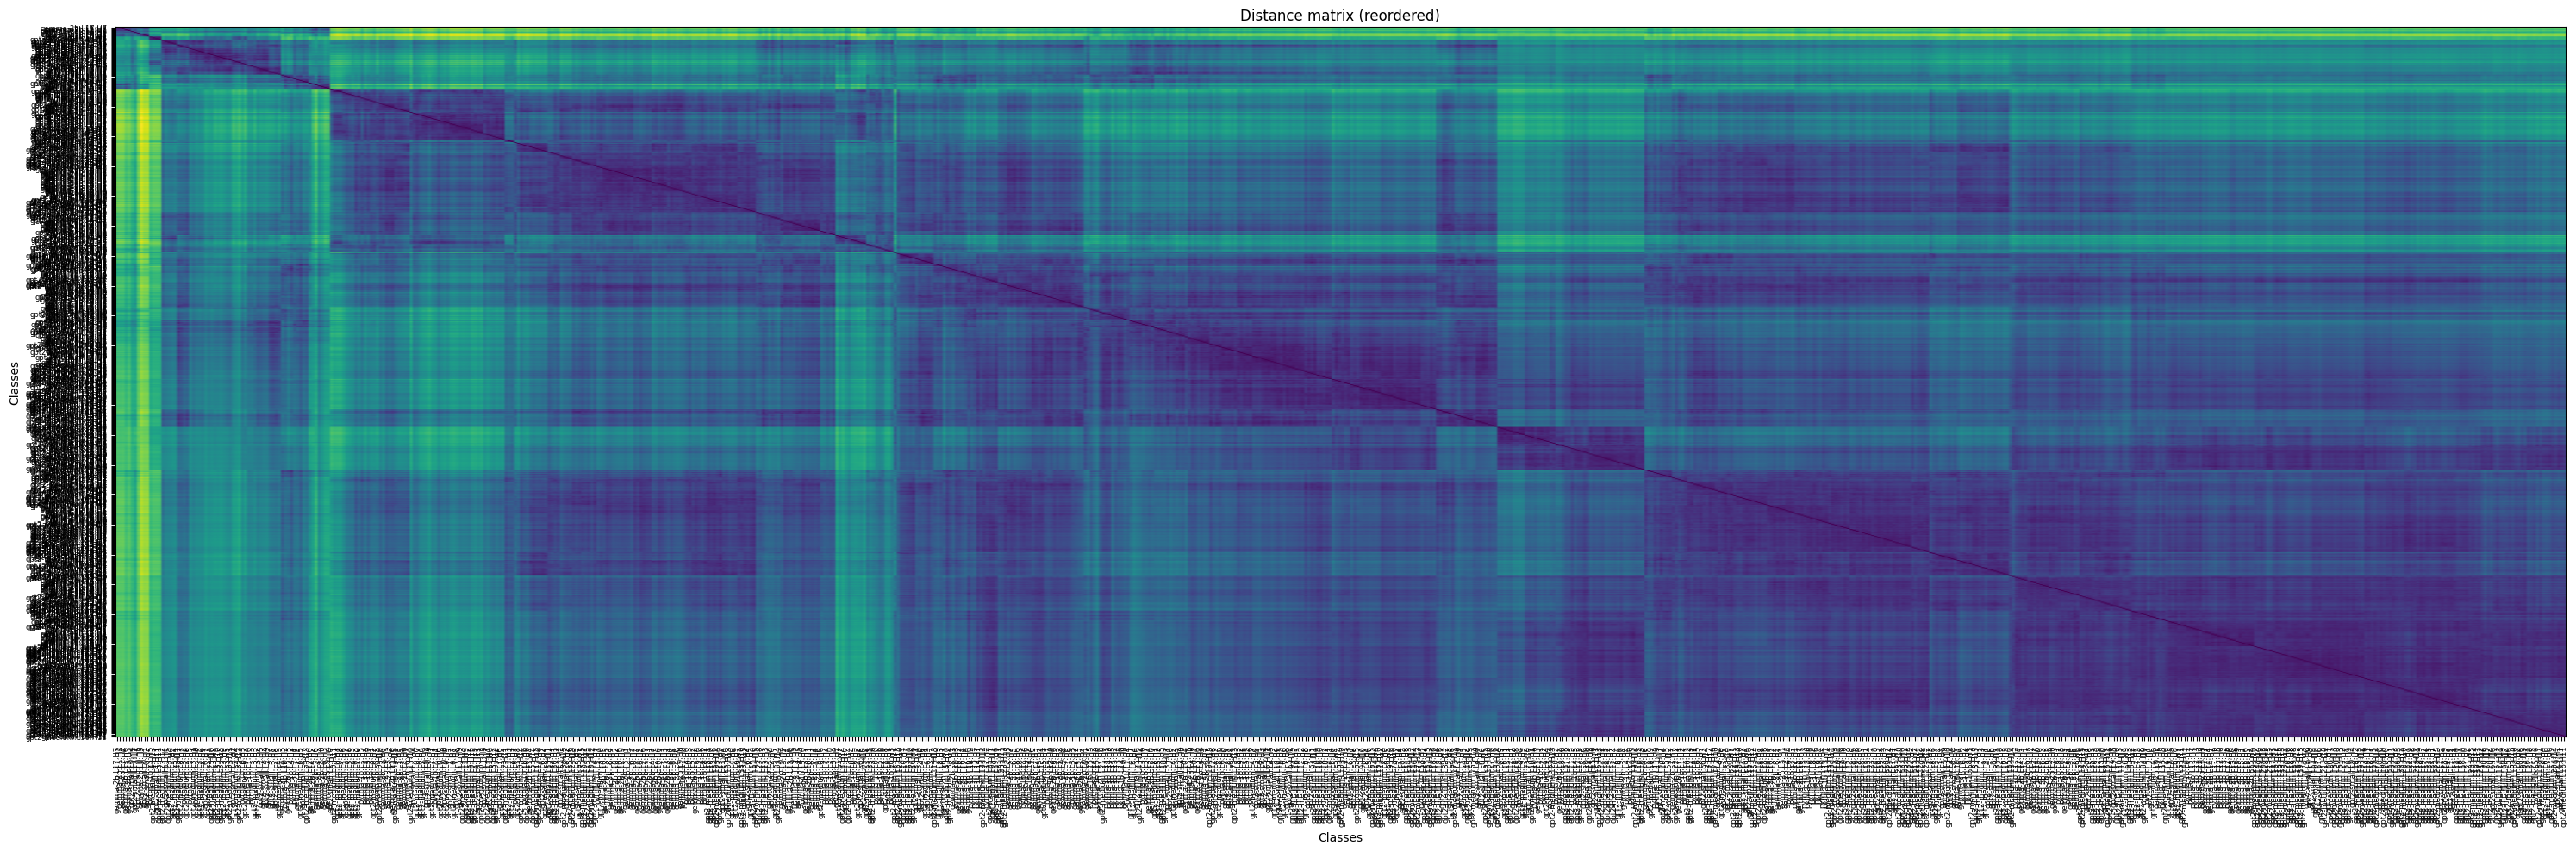

array([[4.17000000e+02, 4.24000000e+02, 1.22315135e+00, 2.00000000e+00],
       [1.89000000e+02, 1.93000000e+02, 1.61594823e+00, 2.00000000e+00],
       [1.22000000e+02, 1.24000000e+02, 1.62656278e+00, 2.00000000e+00],
       ...,
       [1.59000000e+03, 1.59400000e+03, 1.63839509e+01, 7.46000000e+02],
       [1.59500000e+03, 1.59600000e+03, 1.68106368e+01, 7.89000000e+02],
       [1.59100000e+03, 1.59700000e+03, 2.59986450e+01, 8.00000000e+02]])

In [ ]:
def plot_hclust(
	dist_mat: np.ndarray,
	labels: list[str],
	*,
	method: str = "average",
	leaf_font_size: int = 6,
	truncate: int | None = None,
	show_heatmap: bool = True,
	figsize: tuple[int, int] | None = None,
) -> np.ndarray:
	"""
	Make a dendrogram (and optional reordered heat-map) from a distance matrix.

	Parameters
	----------
	dist_mat : (h, h) ndarray  – symmetric, zero diagonal
	labels   : list[str]      – length h, row/column names
	method   : str            – linkage criterion (avg/single/complete/ward…)
	leaf_font_size : int      – font size used for tick labels
	truncate : int | None     – cap the dendrogram to the last *truncate* leaves
	show_heatmap : bool       – skip heat-map when h is too large
	figsize  : tuple[int, int]|None – if None, size is chosen automatically

	Returns
	-------
	Z : ndarray               – SciPy linkage matrix (h-1, 4)
	"""
	h: int = dist_mat.shape[0]
	if dist_mat.shape != (h, h):
		raise ValueError("dist_mat must be square")
	if len(labels) != h:
		raise ValueError("labels length must match dist_mat")
	if not np.allclose(dist_mat, dist_mat.T):
		raise ValueError("dist_mat must be symmetric")
	if not np.all(np.diag(dist_mat) == 0):
		raise ValueError("dist_mat diagonal must be zero")

	# linkage --------------------------------------------------------------
	condensed: np.ndarray = squareform(dist_mat, checks=False)
	Z: np.ndarray = linkage(condensed, method=method)

	# pick a reasonable figure size ---------------------------------------
	if figsize is None:
		width = max(10, min(0.05 * h, 30))  # 20 labels → 11 in, 800 → 30 in
		height = 5 if not show_heatmap else 10
		figsize = (width, height)

	# dendrogram -----------------------------------------------------------
	plt.figure(figsize=figsize)
	dend_kw: dict[str, object] = {
		"labels": labels,
		"leaf_rotation": 90,
		"leaf_font_size": leaf_font_size,
		"distance_sort": "ascending",
	}
	if truncate is not None:
		dend_kw.update({"truncate_mode": "lastp", "p": truncate})

	dendro = dendrogram(Z, **dend_kw)
	plt.ylabel("Distance")
	plt.title(f"Hierarchical clustering ({method} linkage)")
	plt.tight_layout()
	plt.show()

	# heat-map -------------------------------------------------------------
	if show_heatmap:
		order: list[int] = dendro["leaves"]
		reordered: np.ndarray = dist_mat[np.ix_(order, order)]

		plt.figure(figsize=figsize)
		plt.imshow(reordered, aspect="auto")  # default colormap
		plt.xticks(
			np.arange(h),
			[labels[i] for i in order],
			rotation=90,
			fontsize=leaf_font_size,
		)
		plt.yticks(
			np.arange(h),
			[labels[i] for i in order],
			fontsize=leaf_font_size,
		)
		plt.xlabel("Classes")
		plt.ylabel("Classes")
		plt.title("Distance matrix (reordered)")
		plt.tight_layout()
		plt.show()

	return Z


plot_hclust(
	head_dists.distances.mean(axis=-1),
	labels=head_dists.cls_values,
)